### 6. Perform density-based clustering algorithm on a downloaded dataset and evaluate the cluster quality by changing the algorithm's parameters.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors

In [2]:
# Load and prepare data
df = pd.read_excel('Mall Customers.xlsx')
print("Dataset Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Dataset Shape: (200, 7)
Columns: ['CustomerID', 'Gender', 'Age', 'Education ', 'Marital Status', 'Annual Income (k$)', 'Spending Score (1-100)']


,CustomerID,Gender,Age,Education,Marital Status,Annual Income (k$),Spending Score (1-100)
0,1,M,19,High School,Married,15,39
1,2,M,21,Graduate,Single,15,81
2,3,F,20,Graduate,Married,16,6
3,4,F,23,High School,Unknown,16,77
4,5,F,31,Uneducated,Married,17,40


In [3]:
# Select and scale features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Scaled data shape:", X_scaled.shape)

Scaled data shape: (200, 2)


In [4]:
# Helper function to evaluate DBSCAN
def evaluate_dbscan(X, eps, min_samples):
    labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    
    # Calculate silhouette score (needs at least 2 clusters, excluding noise)
    mask = labels != -1
    silhouette = silhouette_score(X[mask], labels[mask]) if n_clusters >= 2 and sum(mask) > n_clusters else None
    return n_clusters, n_noise, silhouette, labels

In [5]:
# Evaluate by varying eps (epsilon)
print("Effect of varying eps (min_samples=5):")
print("-" * 45)
for eps in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    n_clusters, n_noise, sil, _ = evaluate_dbscan(X_scaled, eps, 5)
    sil_str = f"{sil:.3f}" if sil else "N/A"
    print(f"eps={eps}: Clusters={n_clusters}, Noise={n_noise}, Silhouette={sil_str}")

Effect of varying eps (min_samples=5):
---------------------------------------------
eps=0.3: Clusters=7, Noise=35, Silhouette=0.524
eps=0.4: Clusters=4, Noise=15, Silhouette=0.478
eps=0.5: Clusters=2, Noise=8, Silhouette=0.388
eps=0.6: Clusters=1, Noise=5, Silhouette=N/A
eps=0.7: Clusters=1, Noise=0, Silhouette=N/A
eps=0.8: Clusters=1, Noise=0, Silhouette=N/A


In [6]:
# Evaluate by varying min_samples
print("Effect of varying min_samples (eps=0.5):")
print("-" * 50)
for min_samples in [3, 4, 5, 6, 7, 10]:
    n_clusters, n_noise, sil, _ = evaluate_dbscan(X_scaled, 0.5, min_samples)
    sil_str = f"{sil:.3f}" if sil else "N/A"
    print(f"min_samples={min_samples}: Clusters={n_clusters}, Noise={n_noise}, Silhouette={sil_str}")

Effect of varying min_samples (eps=0.5):
--------------------------------------------------
min_samples=3: Clusters=2, Noise=7, Silhouette=0.389
min_samples=4: Clusters=2, Noise=8, Silhouette=0.388
min_samples=5: Clusters=2, Noise=8, Silhouette=0.388
min_samples=6: Clusters=2, Noise=11, Silhouette=0.401
min_samples=7: Clusters=2, Noise=12, Silhouette=0.394
min_samples=10: Clusters=4, Noise=21, Silhouette=0.511


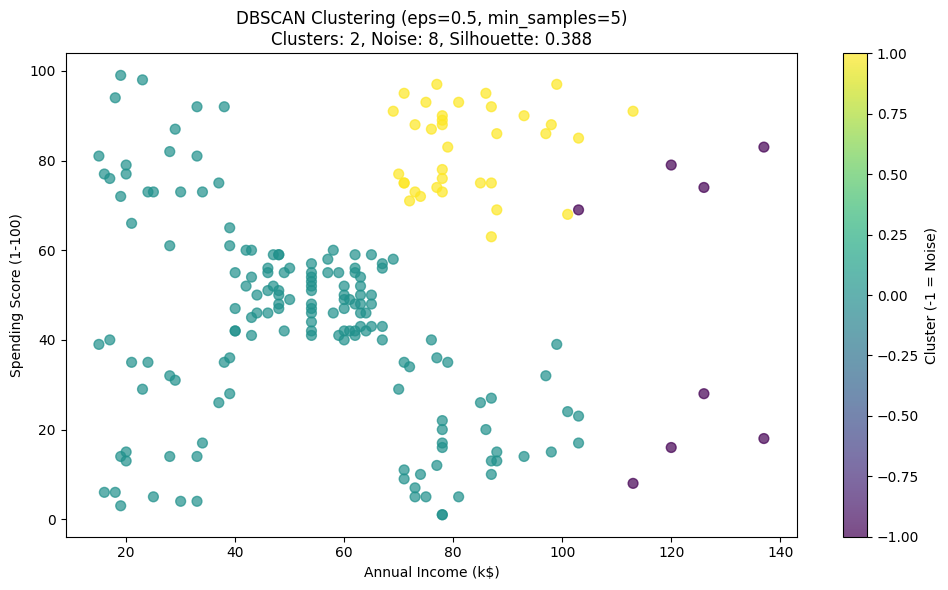

In [7]:
# Visualize final clustering with chosen parameters
eps, min_samples = 0.5, 5
n_clusters, n_noise, sil, labels = evaluate_dbscan(X_scaled, eps, min_samples)

plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', alpha=0.7, s=50)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title(f'DBSCAN Clustering (eps={eps}, min_samples={min_samples})\nClusters: {n_clusters}, Noise: {n_noise}, Silhouette: {sil:.3f}')
plt.colorbar(label='Cluster (-1 = Noise)')
plt.tight_layout()
plt.show()